<a href="https://colab.research.google.com/github/dasakorol06-hue/Walmart/blob/main/%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BF%D1%80%D0%BE%D0%B4%D0%B0%D0%B6_Walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [86]:
df = pd.read_csv('Walmart-sales.csv', sep=',', encoding='utf-8')
print("Информация о колонках:")
print(df.info())
print("Первые 5 строк:")
print(df.head())

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 785.4+ KB
None
Первые 5 строк:
   invoice_id   Branch         City                category unit_price  \
0           1  WALM003  San Antonio       Health and beauty     $74.69   
1           2  WALM048    Harlingen  Electronic accessories     $15.28   
2           3  WALM06

In [87]:
def clean_price(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '.').strip()
        x = ''.join(c for c in x if c.isdigit() or c == '.')
    return x
df['unit_price'] = df['unit_price'].apply(clean_price)
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

df = df.dropna(subset=['unit_price', 'quantity'])
print(f"После удаления пропусков: {df.shape[0]} строк")

df['quantity'] = df['quantity'].round().astype(int)

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%y', errors='coerce')

После удаления пропусков: 10020 строк


In [88]:
df['total'] = df['unit_price'] * df['quantity']

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.hour

print("Типы данных после очистки:")
print(df.dtypes)

Типы данных после очистки:
invoice_id                 int64
Branch                    object
City                      object
category                  object
unit_price               float64
quantity                   int64
date              datetime64[ns]
time                      object
payment_method            object
rating                   float64
total                    float64
year                       int32
month                      int32
day                        int32
day_of_week                int32
hour                       int32
dtype: object


Выручка по категориям

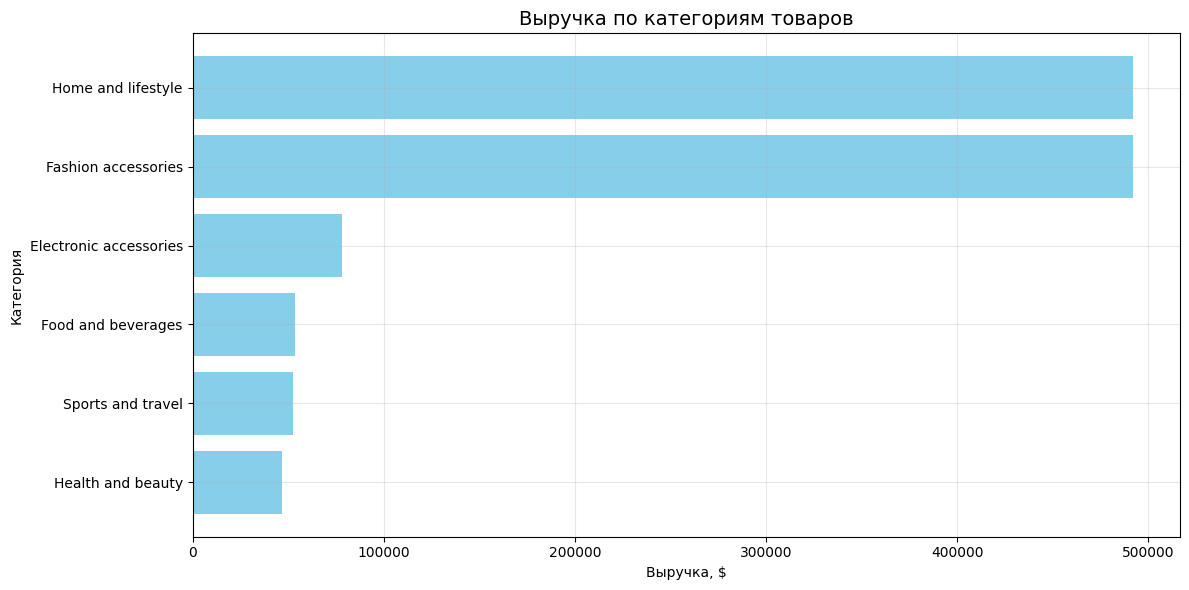

In [89]:
plt.figure(figsize=(12, 6))
category_sales = df.groupby('category')['total'].sum().sort_values(ascending=True)
plt.barh(category_sales.index, category_sales.values, color='skyblue')
plt.title('Выручка по категориям товаров', fontsize=14)
plt.xlabel('Выручка, $')
plt.ylabel('Категория')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Сезонность по месяцам

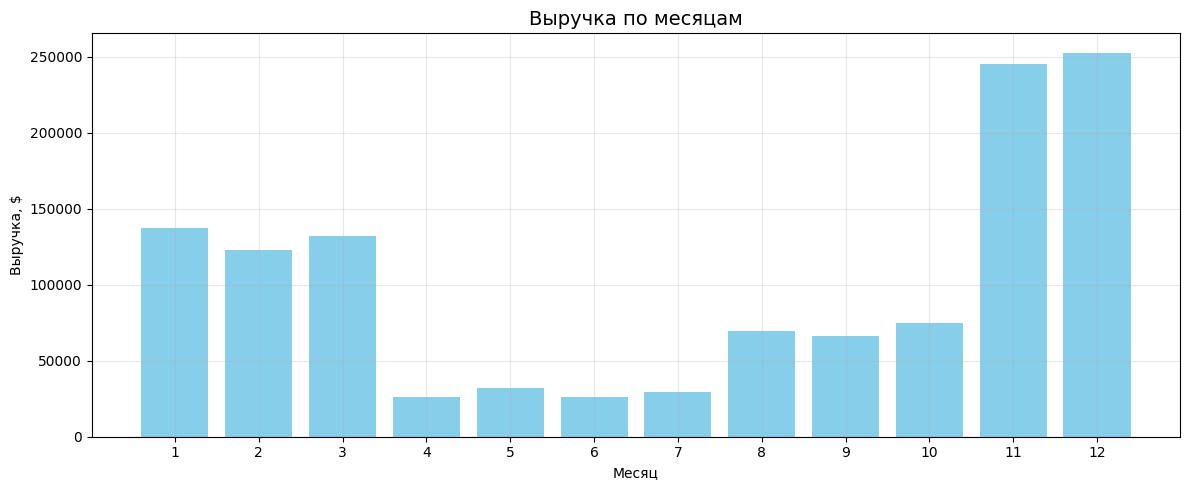

In [90]:
plt.figure(figsize=(12, 5))
monthly_sales = df.groupby('month')['total'].sum()
plt.bar(monthly_sales.index, monthly_sales.values, color='skyblue')
plt.title('Выручка по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Выручка, $')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Корреляционная матрица

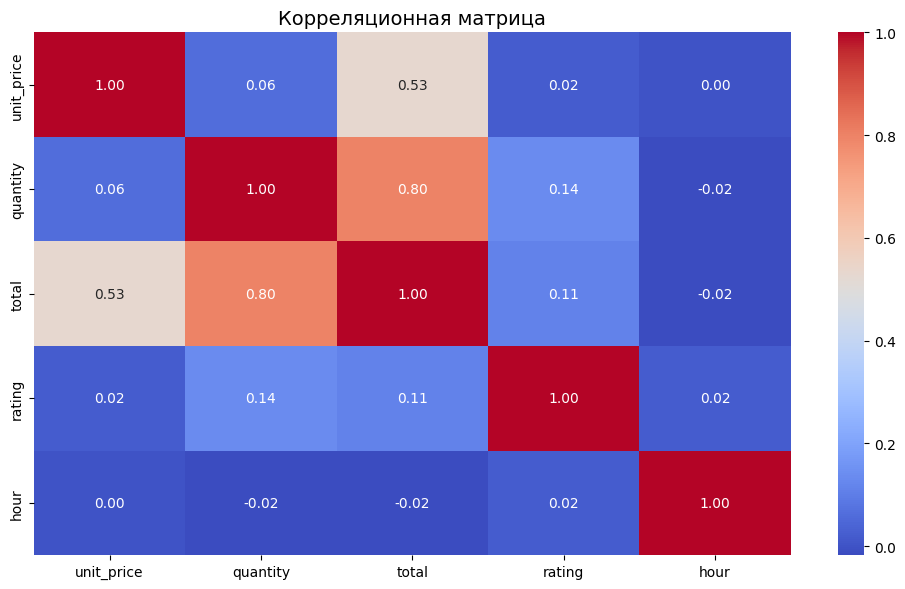

In [91]:
plt.figure(figsize=(10, 6))
correlation_cols = ['unit_price', 'quantity', 'total', 'rating']
if 'hour' in df.columns:
    correlation_cols.append('hour')
corr_matrix = df[correlation_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()

Анализ времени покупок

In [95]:
total_revenue = df['total'].sum()
total_orders = len(df)
avg_check = df['total'].mean()
avg_rating = df['rating'].mean()
unique_products = df['category'].nunique()

print(f"Общая выручка: {total_revenue:,.2f}$")
print(f"Всего заказов: {total_orders:}")
print(f"Средний чек: {avg_check:.2f}$")
print(f"Средний рейтинг: {avg_rating:.2f} из 10")
print(f"Категорий товаров: {unique_products}")

Общая выручка: 1,214,825.38$
Всего заказов: 10020
Средний чек: 121.24$
Средний рейтинг: 5.82 из 10
Категорий товаров: 6


Динамика по месяцам

In [99]:
df['year_month'] = df['date'].dt.strftime('%Y-%m')

monthly_stats = df.groupby('year_month').agg({
    'total': 'sum',
    'invoice_id': 'count',
    'rating': 'mean'
}).rename(columns={
    'total': 'Revenue',
    'invoice_id': 'Orders',
    'rating': 'Rating'
}).round(2)

print(monthly_stats)

              Revenue  Orders  Rating
year_month                           
2019-01     110754.16     352    7.02
2019-02      92589.88     303    7.07
2019-03     104243.34     345    6.84
2020-01       6771.00      73    6.11
2020-02       7087.00      76    5.88
2020-03       6188.00      65    6.17
2020-04       7270.00      74    6.04
2020-05       8548.00      77    5.97
2020-06       5434.00      63    5.89
2020-07       7186.00      78    6.04
2020-08      16857.00     172    6.31
2020-09      15643.00     156    6.01
2020-10      18532.00     179    6.24
2020-11      60187.00     606    5.29
2020-12      60783.00     604    5.36
2021-01       7568.00      76    5.82
2021-02       8428.00      75    6.16
2021-03       7518.00      76    5.95
2021-04       6588.00      71    5.80
2021-05       7208.00      69    5.81
2021-06       6671.00      65    5.66
2021-07       8367.00      81    5.93
2021-08      16843.00     173    6.58
2021-09      17949.00     180    6.27
2021-10     

Топ-5 категорий по выручке

In [102]:
top_categories = df.groupby('category')['total'].sum().sort_values(ascending=False).head(5)
for cat, rev in top_categories.items():
    print(f"{cat}:{rev:,.2f} $ ({rev/total_revenue*100:.1f}%)")

Home and lifestyle:491,996.06 $ (40.5%)
Fashion accessories:491,833.90 $ (40.5%)
Electronic accessories:78,175.03 $ (6.4%)
Food and beverages:53,471.28 $ (4.4%)
Sports and travel:52,497.93 $ (4.3%)


Статистика по филиалам

In [104]:
branch_stats = df.groupby('Branch').agg({
    'total': 'sum',
    'invoice_id': 'count',
    'rating': 'mean'
}).rename(columns={
    'total': 'Revenue',
    'invoice_id': 'Orders',
    'rating': 'Rating'
}).round(2)

print(branch_stats)

          Revenue  Orders  Rating
Branch                           
WALM001  10225.68      74    6.30
WALM002   7734.12      65    6.18
WALM003  25001.56     187    5.36
WALM004   7565.65      60    7.00
WALM005  11654.64      84    6.58
...           ...     ...     ...
WALM096  11256.17      79    6.20
WALM097   7376.91      67    6.16
WALM098   9509.93      65    6.32
WALM099  18389.60     168    5.08
WALM100   8254.34      62    6.21

[100 rows x 3 columns]


Анализ способов оплаты

In [106]:
payment_stats = df['payment_method'].value_counts()
for method, count in payment_stats.items():
    print(f"{method}: {count} ({count/len(df)*100:.1f}%)")

Credit card: 4259 (42.5%)
Ewallet: 3881 (38.7%)
Cash: 1880 (18.8%)


Способы оплаты

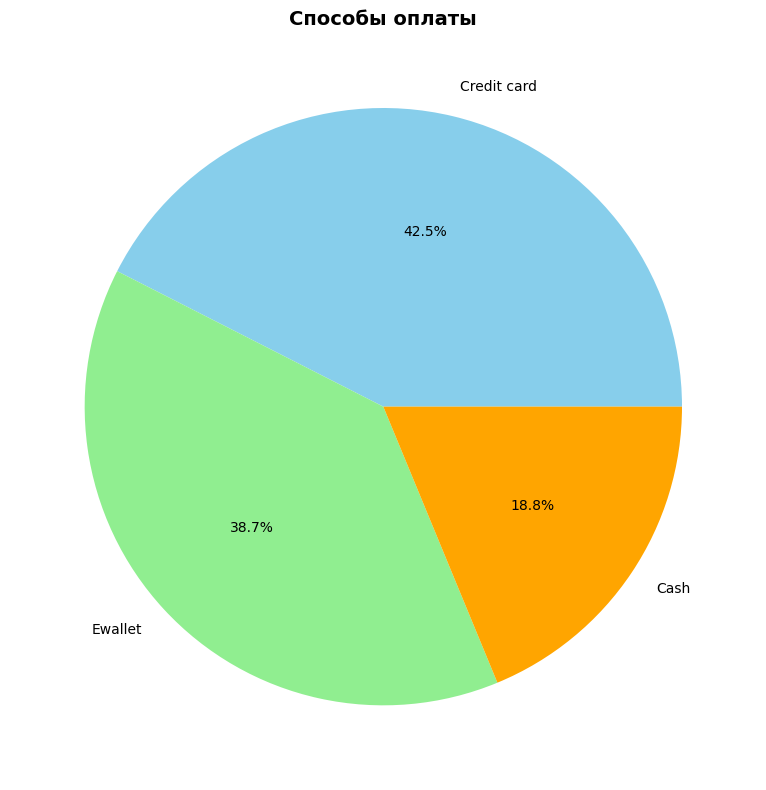

In [120]:
plt.figure(figsize=(8, 8))
plt.pie(payment_stats.values, labels=payment_stats.index, autopct='%1.1f%%',
        colors=['skyblue', 'lightgreen', 'orange'])
plt.title('Способы оплаты', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Выручка по способам оплаты

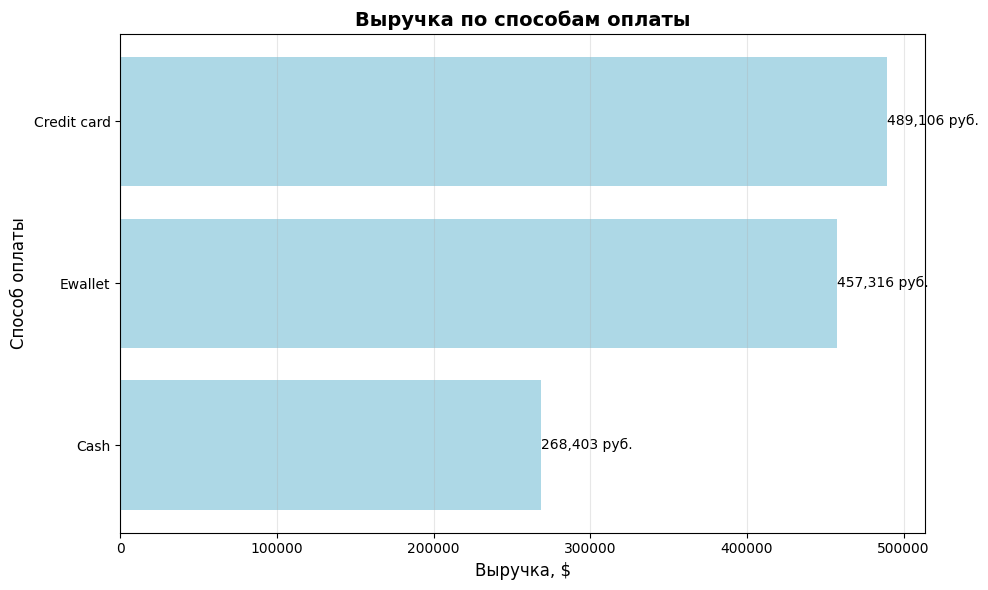

In [128]:
plt.figure(figsize=(10, 6))
payment_revenue = df.groupby('payment_method')['total'].sum().sort_values()
plt.barh(payment_revenue.index, payment_revenue.values, color='lightblue')
plt.title('Выручка по способам оплаты', fontsize=14, fontweight='bold')
plt.xlabel('Выручка, $', fontsize=12)
plt.ylabel('Способ оплаты', fontsize=12)

for i, val in enumerate(payment_revenue.values):
    plt.text(val + 100, i, f'{val:,.0f} руб.', va='center', fontsize=10)

plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Заказы по часам

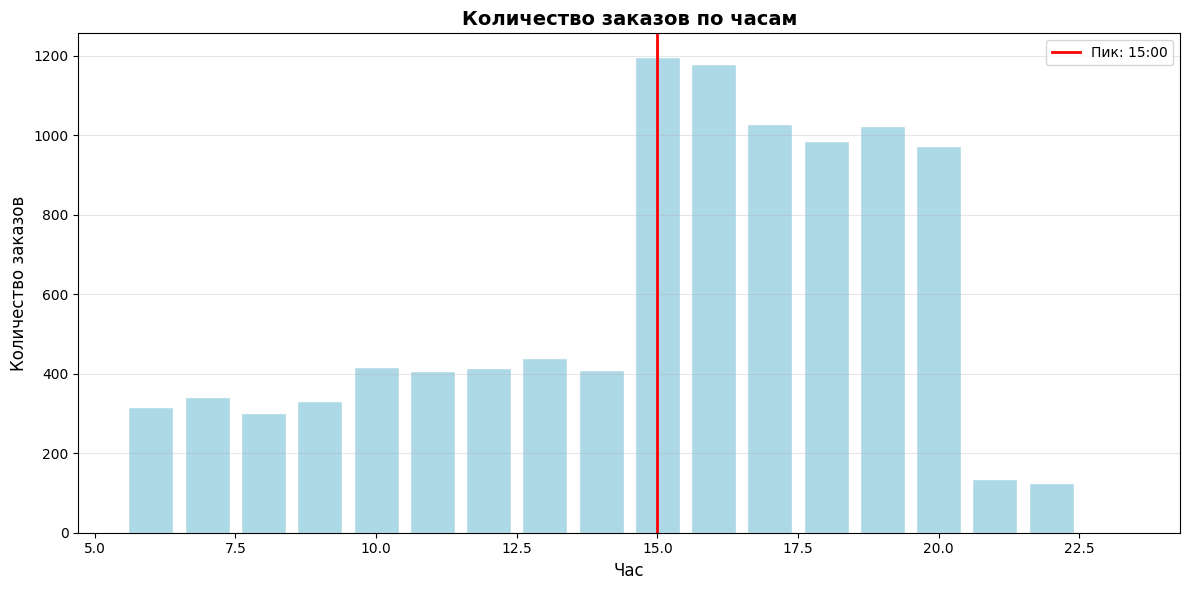

In [127]:
plt.figure(figsize=(12, 6))
hourly_orders = df.groupby('hour')['invoice_id'].count()
plt.bar(hourly_orders.index, hourly_orders.values, color='lightblue', edgecolor='white')
plt.axvline(x=hourly_orders.idxmax(), color='red', linewidth=2, label=f'Пик: {hourly_orders.idxmax()}:00')
plt.title('Количество заказов по часам', fontsize=14, fontweight='bold')
plt.xlabel('Час', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [126]:
best_category = top_categories.index[0]
best_branch = branch_stats['Revenue'].idxmax()
best_month = monthly_stats['Revenue'].idxmax()

print(f"""
1.Основные выводы:
Лидер по выручке: категория «{best_category}» ({top_categories[0]:,.2f} руб.)
Лучший филиал: {best_branch} ({branch_stats.loc[best_branch, 'Revenue']:,.2f} руб.)
Пиковый месяц: {best_month} ({monthly_stats.loc[best_month, 'Revenue']:,.2f} руб.)
Средний чек: {avg_check:.2f} руб.

2.Рекомендации:
Увеличить ассортимент в категории «{best_category}» для роста выручки
Провести акции в филиалах с низкой выручкой
Изучить опыт лучшего филиала {best_branch} для масштабирования

3.Потенциал роста:
Увеличение среднего чека на 10% даст прирост выручки на {total_revenue * 0.1:,.0f} руб.
Оптимизация работы в часы пик""")


1.Основные выводы:
Лидер по выручке: категория «Home and lifestyle» (491,996.06 руб.)
Лучший филиал: WALM074 (25,732.42 руб.)
Пиковый месяц: 2019-01 (110,754.16 руб.)
Средний чек: 121.24 руб.

2.Рекомендации:
Увеличить ассортимент в категории «Home and lifestyle» для роста выручки
Провести акции в филиалах с низкой выручкой
Изучить опыт лучшего филиала WALM074 для масштабирования

3.Потенциал роста:
Увеличение среднего чека на 10% даст прирост выручки на 121,483 руб.
Оптимизация работы в часы пик
